<!-- Cell 0 -->

# 3D Gaussian Splatting -- A Hands-On Tutorial

This notebook builds [3D Gaussian Splatting](https://repo-sam.inria.fr/fungraph/3d-gaussian-splatting/) (Kerbl et al., 2023) from scratch, in plain PyTorch, using only a random point-cloud initialization (no COLMAP / structure-from-motion needed to get started -- see the note near the end about adding that back in).

**What you need**: this notebook, `tiny_nerf_data.npz` sitting next to it, and `numpy` / `torch` / `pillow` / `matplotlib`. No GPU, no CUDA, no external tools.

**What you'll build, in order**:
1. A camera model matching the dataset's photos and poses
2. Spherical harmonics -- how a gaussian's color can depend on viewing direction
3. The gaussian primitive itself, and a random initial point cloud
4. Projecting 3D gaussians into 2D screen space (the "EWA splatting" math)
5. Rendering: alpha-compositing many gaussians into one image
6. A photometric loss to compare a render against a real photo
7. The training loop that ties it all together
8. Adaptive density control -- letting the model grow/shrink its own gaussian count
9. Results: held-out evaluation and a novel-view orbit render

Expect ~5-15 minutes of CPU compute once you reach Section 7.

In [1]:
# Cell 1
# %pip install numpy torch pillow matplotlib   # uncomment if any of these are missing

import math
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

<!-- Cell 2 -->

## 0. Load the data

`tiny_nerf_data.npz` (the classic NeRF "Lego bulldozer" scene) contains 106 photos of a synthetic scene at 100x100 resolution, each with a known ground-truth camera pose. Real 3DGS pipelines get poses (and an initial point cloud) from COLMAP structure-from-motion; here we take the poses as given so we can focus on the gaussian-splatting math itself. We'll downsample further, to 25x25, right after loading -- see the comment in the next cell for why.

In [2]:
# Cell 3
NPZ_PATH = Path("tiny_nerf_data.npz")
raw = np.load(NPZ_PATH)
images, poses, focal = raw["images"], raw["poses"], float(raw["focal"])

# Downsample from the source 100x100: Section 5's render() evaluates every
# gaussian over the *whole* image at once (no per-gaussian pixel cropping,
# which keeps that code simple), so its cost scales with image size --
# working at 25x25 instead keeps training time reasonable. Average each
# non-overlapping 4x4 block of pixels into one; the focal length (in pixels)
# shrinks by the same factor.
DOWNSAMPLE_FACTOR = 4
n, h, w, c = images.shape
images = images.reshape(n, h // DOWNSAMPLE_FACTOR, DOWNSAMPLE_FACTOR,
                         w // DOWNSAMPLE_FACTOR, DOWNSAMPLE_FACTOR, c).mean(axis=(2, 4))
focal /= DOWNSAMPLE_FACTOR

N, H, W = images.shape[:3]
print(f"{N} views, {H}x{W} resolution, focal length {focal:.2f}px")

106 views, 25x25 resolution, focal length 34.72px


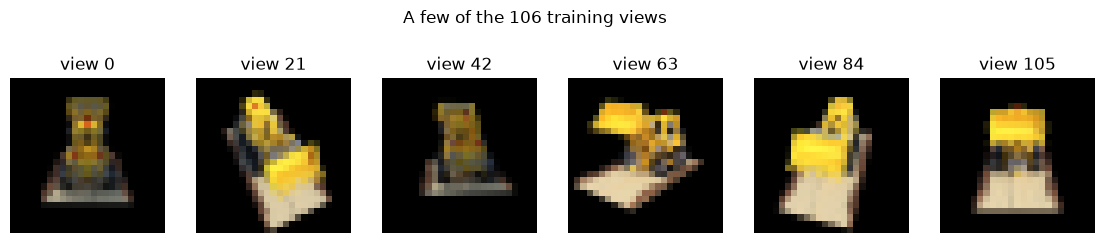

In [3]:
# Cell 4
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, idx in zip(axes, np.linspace(0, N - 1, 6).astype(int)):
    ax.imshow(images[idx])
    ax.set_title(f"view {idx}")
    ax.axis("off")
plt.suptitle("A few of the 106 training views")
plt.show()

<!-- Cell 5 -->

## 1. Cameras

Each photo has:
- **Intrinsics**: focal length + principal point (`fx, fy, cx, cy`) -- how 3D points project onto the pixel grid.
- **Extrinsics**: where the camera is and which way it's pointing, as a rotation `R` and translation `t`.

There's a subtlety worth getting right immediately: this dataset's poses are stored **camera-to-world**, in the "OpenGL" convention (camera looks down its own **-Z** axis, **Y** up) -- the convention Blender/NeRF papers use. We'll convert once, up front, to **world-to-camera**, "OpenCV" convention (camera looks down **+Z**, **Y** down) -- the convention COLMAP uses. Doing this conversion now, rather than working directly in the OpenGL convention, means that if you later swap in real COLMAP poses/points (see the note in Section 3), none of the camera or rendering math below needs to change -- only where the points come from.

Same local **X** (right) in both -- only **Y** and **Z** flip:

<svg width="460" height="175" xmlns="http://www.w3.org/2000/svg">
  <defs>
    <marker id="ar-red" markerWidth="6" markerHeight="6" refX="5" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 Z" fill="#d62728"/></marker>
    <marker id="ar-green" markerWidth="6" markerHeight="6" refX="5" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 Z" fill="#2ca02c"/></marker>
    <marker id="ar-blue" markerWidth="6" markerHeight="6" refX="5" refY="3" orient="auto"><path d="M0,0 L6,3 L0,6 Z" fill="#1f77b4"/></marker>
  </defs>
  <g transform="translate(85,90)" font-family="sans-serif" font-size="12" fill="#888888">
    <text x="-65" y="-65">OpenGL: Y up, looks down -Z</text>
    <line x1="0" y1="0" x2="55" y2="0" stroke="#d62728" stroke-width="2" marker-end="url(#ar-red)"/>
    <text x="60" y="4">X</text>
    <line x1="0" y1="0" x2="0" y2="-55" stroke="#2ca02c" stroke-width="2" marker-end="url(#ar-green)"/>
    <text x="5" y="-60">Y</text>
    <line x1="0" y1="0" x2="-38" y2="38" stroke="#1f77b4" stroke-width="2" marker-end="url(#ar-blue)"/>
    <text x="-52" y="52">Z</text>
    <circle cx="0" cy="0" r="3"/>
  </g>
  <g transform="translate(330,90)" font-family="sans-serif" font-size="12" fill="#888888">
    <text x="-68" y="-65">OpenCV: Y down, looks down +Z</text>
    <line x1="0" y1="0" x2="55" y2="0" stroke="#d62728" stroke-width="2" marker-end="url(#ar-red)"/>
    <text x="60" y="4">X</text>
    <line x1="0" y1="0" x2="0" y2="55" stroke="#2ca02c" stroke-width="2" marker-end="url(#ar-green)"/>
    <text x="5" y="70">Y</text>
    <line x1="0" y1="0" x2="38" y2="-38" stroke="#1f77b4" stroke-width="2" marker-end="url(#ar-blue)"/>
    <text x="43" y="-42">Z</text>
    <circle cx="0" cy="0" r="3"/>
  </g>
</svg>

In [4]:
# Cell 6
@dataclass
class Camera:
    name: str
    width: int
    height: int
    fx: float
    fy: float
    cx: float
    cy: float
    R: np.ndarray  # (3,3) world -> camera rotation
    t: np.ndarray  # (3,)  world -> camera translation
    image: np.ndarray  # (H,W,3) float32 in [0,1], ground-truth photo (None for synthetic novel views)

    @property
    def camera_center(self) -> np.ndarray:
        """Camera position in world space."""
        return -self.R.T @ self.t


def nerf_c2w_to_w2c(c2w: np.ndarray):
    """OpenGL-convention camera-to-world -> OpenCV-convention world-to-camera.
    A fixed local Y,Z axis flip, then matrix inversion."""
    flip = np.diag([1.0, -1.0, -1.0])
    R_c2w = c2w[:3, :3] @ flip
    t_c2w = c2w[:3, 3]
    R_w2c = R_c2w.T
    t_w2c = -R_w2c @ t_c2w
    return R_w2c, t_w2c


cx, cy = W / 2.0, H / 2.0
cameras = []
for i in range(N):
    R, t = nerf_c2w_to_w2c(poses[i])
    cameras.append(Camera(name=f"view_{i:03d}", width=W, height=H, fx=focal, fy=focal,
                           cx=cx, cy=cy, R=R, t=t, image=images[i].astype(np.float32)))

# A handful of views held out entirely from training, for an honest quality check later.
TEST_HOLDOUT_STRIDE = 8
train_cameras = [c for i, c in enumerate(cameras) if i % TEST_HOLDOUT_STRIDE != 0]
test_cameras = [c for i, c in enumerate(cameras) if i % TEST_HOLDOUT_STRIDE == 0]
print(f"{len(train_cameras)} train views, {len(test_cameras)} held-out test views")

92 train views, 14 held-out test views


<!-- Cell 7 -->

### Why both `focal` (one number) and `fx`/`fy` (one pair per camera)?

They're not actually different in *value* here -- every `Camera` above was built with `fx=focal, fy=focal`. The distinction is structural, not numerical, for this particular dataset:

- **`focal`** is what the raw data gives us: this synthetic scene was rendered with a single fixed virtual camera (same lens/sensor) just moved to 106 different positions, so the `.npz` stores exactly one focal length, shared by every view.
- **`fx`/`fy` on each `Camera`** is what the general camera model (and all the projection math in Section 4 onward) actually reads -- stored *per camera* rather than as one global constant, because in general a dataset's intrinsics don't have to be shared: a real phone-camera capture can autofocus/zoom differently per shot, and COLMAP can estimate a slightly different focal length per image. Keeping `fx`/`fy` per-camera means the code doesn't need to special-case "this dataset happens to share one focal length" -- it already works if it didn't.
- **`fx` vs `fy` being two separate numbers** (rather than one shared "focal") accounts for non-square pixels / a different horizontal vs. vertical field of view -- again irrelevant here (`fx == fy` exactly), but the projection math doesn't assume they're equal.

A quick check that this dataset really is as uniform as claimed:

In [5]:
# Cell 8
all_equal = all(c.fx == focal and c.fy == focal for c in cameras)
print(f"All {len(cameras)} cameras: fx == fy == focal ({focal:.4f})?  {all_equal}")

All 106 cameras: fx == fy == focal (34.7222)?  True


<!-- Cell 9 -->

## 2. Spherical harmonics: color as a function of viewing direction

A real surface doesn't always look the same color from every angle -- think of a shiny plastic toy with specular highlights. 3DGS represents each gaussian's color not as one fixed RGB triplet, but as a small function of viewing direction, built from **spherical harmonics (SH)**: a fixed set of basis functions on the sphere, weighted by learned per-gaussian coefficients.

$$\text{color}(\mathbf{d}) = \sum_{l=0}^{L} \sum_{m=-l}^{l} c_{lm}\, Y_{lm}(\mathbf{d})$$

Degree 0 is a *single* constant basis function -- so a degree-0-only model is exactly a flat, non-view-dependent color. Each higher degree adds more angular detail: a degree `l` has exactly `2l+1` basis functions (1 for degree 0, 3 for degree 1, 5 for degree 2, 7 for degree 3 -- 16 total up to degree 3). We'll start training at degree 0 and ramp up, so the model gets the flat color roughly right before spending capacity on view-dependent detail (Section 7).

<!-- One thing that trips people up in the code below: `C0` and `C1` are each a *single* number, while `C2` and `C3` are *lists* of 5 and 7 numbers. That's not a mismatch with "3 coefficients at degree 1" -- it's a coincidence specific to degree 1: all three of its basis functions (proportional to `x`, `y`, and `z`) happen to share the exact same normalization constant, so the code only needs to store it once and reuse it three times (with different signs and different `x`/`y`/`z` factors -- see `eval_sh` below). Degrees 2 and 3 aren't so lucky -- each of their 5 (or 7) basis functions has its *own* distinct constant, so those really do need a list. -->

The basis functions below are the *real* (not complex) SH basis, written directly as polynomials in a unit direction vector's `x, y, z` components -- this is the same basis (and normalization constants) the original 3DGS authors' code uses.

In [6]:
# Cell 10
# Real SH basis constants, degrees 0-3 (same normalization as the official 3DGS code).
C0 = 0.28209479177387814
C1 = [0.4886025119029199, 0.4886025119029199, 0.4886025119029199]  # same value 3x: degree 1's 3 basis functions (~y, ~z, ~x) share one normalization constant, unlike C2/C3 below where each basis function has its own
C2 = [1.0925484305920792, -1.0925484305920792, 0.31539156525252005,
      -1.0925484305920792, 0.5462742152960396]
C3 = [-0.5900435899266435, 2.890611442640554, -0.4570457994644658,
      0.3731763325901154, -0.4570457994644658, 1.445305721320277,
      -0.5900435899266435]

MAX_SH_DEGREE = 3
NUM_SH_COEFFS = (MAX_SH_DEGREE + 1) ** 2  # 16 coefficients per color channel


def eval_sh(degree, coeffs, dirs):
    """coeffs: (...,16,C) per-band coefficients. dirs: (...,3) unit view
    directions. Returns (...,C). Only the first (degree+1)**2 bands are read,
    which is what lets `degree` grow during training without resizing coeffs."""
    result = C0 * coeffs[..., 0, :]
    if degree > 0:
        x, y, z = dirs[..., 0:1], dirs[..., 1:2], dirs[..., 2:3]
        result = (result - C1[0] * y * coeffs[..., 1, :] + C1[1] * z * coeffs[..., 2, :]
                  - C1[2] * x * coeffs[..., 3, :])
        if degree > 1:
            xx, yy, zz = x * x, y * y, z * z
            xy, yz, xz = x * y, y * z, x * z
            result = (result + C2[0] * xy * coeffs[..., 4, :] + C2[1] * yz * coeffs[..., 5, :]
                      + C2[2] * (2 * zz - xx - yy) * coeffs[..., 6, :]
                      + C2[3] * xz * coeffs[..., 7, :] + C2[4] * (xx - yy) * coeffs[..., 8, :])
            if degree > 2:
                result = (result + C3[0] * y * (3 * xx - yy) * coeffs[..., 9, :]
                          + C3[1] * xy * z * coeffs[..., 10, :]
                          + C3[2] * y * (4 * zz - xx - yy) * coeffs[..., 11, :]
                          + C3[3] * z * (2 * zz - 3 * xx - 3 * yy) * coeffs[..., 12, :]
                          + C3[4] * x * (4 * zz - xx - yy) * coeffs[..., 13, :]
                          + C3[5] * z * (xx - yy) * coeffs[..., 14, :]
                          + C3[6] * x * (xx - 3 * yy) * coeffs[..., 15, :])
    return result


def rgb_to_sh_dc(rgb):
    """Flat RGB in [0,1] -> the one SH coefficient that reproduces it."""
    return (rgb - 0.5) / C0


def sh_to_rgb(sh_eval):
    """Undo the same offset; clamp negative light to 0 (matches the official
    repo) but not the top end -- training compares raw pixel values, only
    display code clips to [0,1]."""
    return (sh_eval + 0.5).clamp(min=0.0)

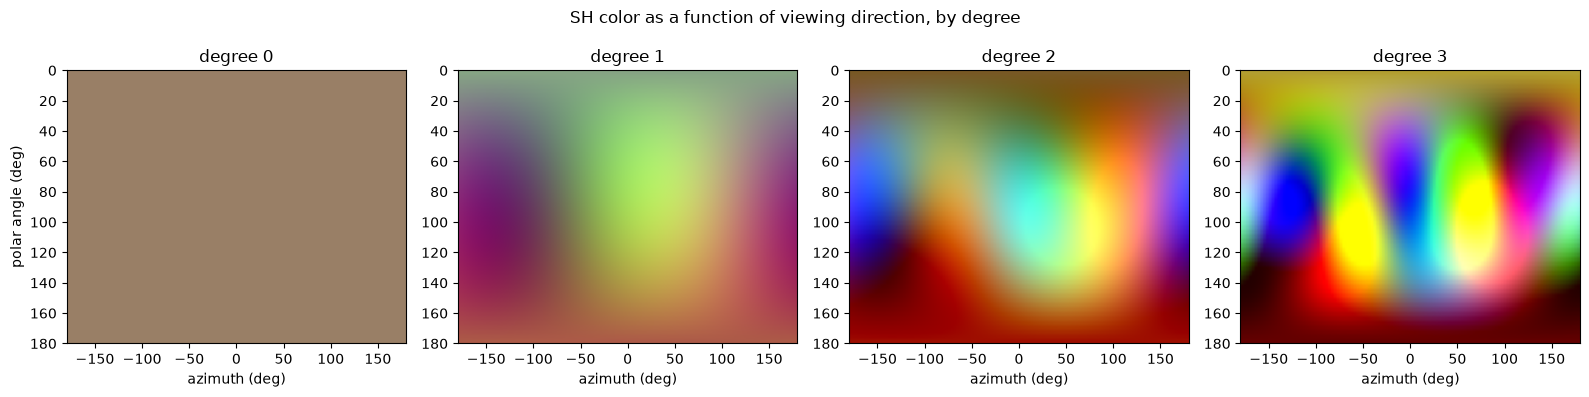

In [7]:
# Cell 11
# Visualize how SH color varies with viewing direction, degree by degree.
# Same random coefficients throughout; each panel adds one more band on top
# of the previous panel's bands (that's what "degree" means for eval_sh).
vis_coeffs = torch.zeros(NUM_SH_COEFFS, 3)
vis_coeffs[0] = rgb_to_sh_dc(torch.tensor([0.6, 0.5, 0.4]))
vis_coeffs[1:] = 0.35 * torch.randn(NUM_SH_COEFFS - 1, 3)

# Sample viewing directions over the whole sphere as an equirectangular
# (polar angle x azimuth) grid, so each panel below is a flattened map of
# "color seen from this direction" -- the SH analogue of a texture lookup.
n_theta, n_phi = 60, 120
theta = torch.linspace(0, math.pi, n_theta)      # polar angle, from +z
phi = torch.linspace(-math.pi, math.pi, n_phi)   # azimuth
theta_grid, phi_grid = torch.meshgrid(theta, phi, indexing="ij")
dirs = torch.stack([
    torch.sin(theta_grid) * torch.cos(phi_grid),
    torch.sin(theta_grid) * torch.sin(phi_grid),
    torch.cos(theta_grid),
], dim=-1)  # (n_theta, n_phi, 3)
coeffs_grid = vis_coeffs.expand(n_theta, n_phi, -1, -1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for degree, ax in enumerate(axes):
    colors = sh_to_rgb(eval_sh(degree, coeffs_grid, dirs)).clamp(0.0, 1.0)
    ax.imshow(colors.numpy(), extent=[-180, 180, 180, 0], aspect="auto")
    ax.set_title(f"degree {degree}")
    ax.set_xlabel("azimuth (deg)")
    if degree == 0:
        ax.set_ylabel("polar angle (deg)")
fig.suptitle("SH color as a function of viewing direction, by degree")
plt.tight_layout()
plt.show()

<!-- Cell 12 -->

## 3. The gaussian primitive

Each gaussian has:
- a **mean** (3D position)
- a **covariance**, factored as $\Sigma = R S S^T R^T$ -- a rotation (unit quaternion) and an axis-aligned scale, so it's always a valid (positive semi-definite) covariance by construction
- an **opacity**
- **SH color coefficients** (Section 2)

<!-- Every parameter is stored **unconstrained** and passed through an activation function on read: we optimize `log(scale)` (so scale via `exp` is always positive), a raw quaternion (normalized to unit length on read), and an opacity *logit* (via `sigmoid`, always in `(0,1)`). This means gradient descent never has to worry about violating a constraint -- the activation function handles it. -->

In [8]:
# Cell 13
def inverse_sigmoid(x):
    x = np.clip(x, 1e-6, 1 - 1e-6)
    return np.log(x / (1 - x))


class GaussianModel(nn.Module):
    def __init__(self, means, log_scales, quats, opacity_logits, features_dc, features_rest):
        super().__init__()

        # Position: where the gaussian is centered in world space.
        self.means = nn.Parameter(torch.as_tensor(means, dtype=torch.float32))

        # Shape: covariance Sigma = R S S^T R^T (Section 3), factored as a unit
        # quaternion (rotation) and an axis-aligned scale so it's always a
        # valid positive-semidefinite covariance no matter what gradient
        # descent does to these numbers.
        self.log_scales = nn.Parameter(torch.as_tensor(log_scales, dtype=torch.float32))
        self.quats = nn.Parameter(torch.as_tensor(quats, dtype=torch.float32))

        # Opacity: how much this gaussian occludes whatever is behind it --
        # the alpha in the alpha-compositing loop in render() (Section 5).
        self.opacity_logits = nn.Parameter(torch.as_tensor(opacity_logits, dtype=torch.float32))

        # Color: spherical-harmonics coefficients (Section 2). features_dc is
        # the degree-0 (view-independent) band, features_rest the degree-1..3
        # (view-dependent) bands -- kept as separate parameters mainly so the
        # optimizer can give them different learning rates (Section 8), since
        # higher-order bands need a much gentler lr to stay stable.
        self.features_dc = nn.Parameter(torch.as_tensor(features_dc, dtype=torch.float32))       # (N,1,3)
        self.features_rest = nn.Parameter(torch.as_tensor(features_rest, dtype=torch.float32))   # (N,15,3)

        self.active_sh_degree = 0  # ramped up to MAX_SH_DEGREE during training (Section 7)

    @property
    def n_gaussians(self):
        return self.means.shape[0]

    def get_scales(self):
        return torch.exp(self.log_scales)

    def get_rotations(self):
        return F.normalize(self.quats, dim=-1)

    def get_opacities(self):
        return torch.sigmoid(self.opacity_logits)

    def get_features(self):
        """(N,16,3): features_dc concatenated with features_rest. Degree-gating
        happens in eval_sh, not here -- keeping the full tensor concatenated is
        what lets active_sh_degree change over training without reallocating."""
        return torch.cat([self.features_dc, self.features_rest], dim=1)

<!-- Cell 14 -->

### Random initialization

A real pipeline gets its starting points from COLMAP structure-from-motion: triangulating real 3D points from features matched across the training photos, so gaussians start out roughly where actual surfaces are. We don't have COLMAP here, but we're not fully blind either: this dataset's background is exactly black, which is free segmentation, and we can use it to figure out roughly where the object sits.

An earlier version of this notebook did that at *notebook run time*: project many candidate points into every training photo, keep only the ones landing on the foreground silhouette in nearly every view (a "visual hull"), and sample color from the photos they land on. It worked well, but it's a lot of machinery to explain for what turns out to be a fairly simple answer. So instead: that visual-hull analysis was run once, offline, and its answer -- a small box, offset from the camera centroid, sized in each axis as a fraction of scene extent -- is hardcoded below. Sampling is back to the simple "uniform random point in a box" of Section 3's original cube init, just a much tighter, better-placed box than a naive guess would give.

This is a real accuracy trade-off, not a free simplification: measured across seeds, the original loose cube (sized purely from camera geometry, no idea where the object actually is) leaves the training loop pruning down to single digits early on; the full runtime visual-hull got that trough up to the hundreds and held-out test L1 down to ~0.027; this hardcoded box lands in between (trough in the tens, test L1 around ~0.031) -- better than guessing blind, worse than actually looking at every photo every time, in exchange for code you can read in ten seconds.

> **Reminder**: like the visual hull it's derived from, this box is still 2D silhouette consistency baked into a fixed offline answer, not real 3D triangulation. Real COLMAP-triangulated points (as the main `gs/` pipeline does) remain the natural next upgrade; nothing else in this notebook needs to change -- only where `random_init_gaussians`'s points come from.

500 box-initialized gaussians


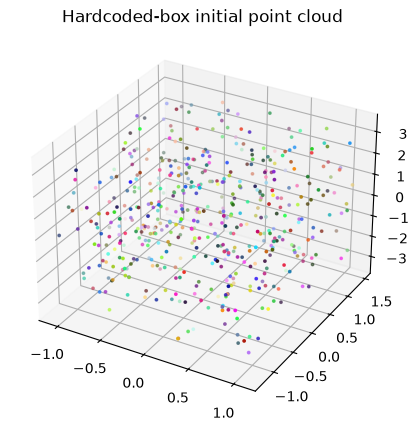

In [9]:
# Cell 15
def compute_scene_extent(cams):
    """Radius of the camera centers about their centroid, x1.1 -- a cheap proxy
    for 'how big is this scene', used to size the initial point cloud and to
    scale a couple of training hyperparameters later."""
    centers = np.stack([c.camera_center for c in cams])
    center = centers.mean(axis=0)
    return float(np.linalg.norm(centers - center, axis=1).max() * 1.1)


N_POINTS_INIT = round(2000 / DOWNSAMPLE_FACTOR)  # fewer initial gaussians for
                                                   # the downsampled image -- less
                                                   # detail to resolve, and it
                                                   # keeps render() (Section 5)
                                                   # cheap since its cost scales
                                                   # with gaussian count too.

# A tight box around where the object actually sits, as fractions of scene
# extent -- the answer a visual-hull silhouette analysis found (see Cell 14),
# hardcoded here instead of recomputed on every run. CENTER_OFFSET_FRAC shifts
# the box away from the camera centroid (the object isn't centered there --
# mostly a big shift along z); HALF_WIDTH_FRAC is deliberately per-axis rather
# than a single cube width, since the object is much shallower in x/y than z.
CENTER_OFFSET_FRAC = np.array([0.058, 0.025, -0.460])
HALF_WIDTH_FRAC = np.array([0.212, 0.269, 0.658])


def random_init_gaussians(cams, n_points=N_POINTS_INIT, init_opacity=0.1):
    centers = np.stack([c.camera_center for c in cams])
    scene_center = centers.mean(axis=0)
    extent = compute_scene_extent(cams)
    box_center = scene_center + CENTER_OFFSET_FRAC * extent
    half_width = HALF_WIDTH_FRAC * extent

    # uniform sampling inside that box: draw x, y, z each independently and
    # uniformly, same as the original cube init, just centered/sized better.
    xyz = (box_center + np.random.uniform(-half_width, half_width, size=(n_points, 3))).astype(np.float32)

    # initial scale: same closed-form spacing heuristic as before (average
    # neighbor spacing if n_points were spread evenly through the box),
    # using the box's own (now much smaller) size instead of the old global extent.
    box_size = 2 * half_width.mean()
    log_scales = np.full((n_points, 3), np.log(box_size / n_points ** (1 / 3)), dtype=np.float32)

    quats = np.zeros((n_points, 4), dtype=np.float32)
    quats[:, 0] = 1.0  # identity rotation (w,x,y,z)

    opacity_logits = np.full((n_points, 1), inverse_sigmoid(np.array(init_opacity)), dtype=np.float32)

    rgb = np.random.rand(n_points, 3).astype(np.float32)  # no COLMAP color signal -- just guess
    features_dc = rgb_to_sh_dc(torch.from_numpy(rgb)).unsqueeze(1).numpy()
    features_rest = np.zeros((n_points, NUM_SH_COEFFS - 1, 3), dtype=np.float32)

    return GaussianModel(xyz, log_scales, quats, opacity_logits, features_dc, features_rest), rgb


gaussians, init_rgb = random_init_gaussians(train_cameras)
print(f"{gaussians.n_gaussians} box-initialized gaussians")

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
xyz = gaussians.means.detach().numpy()
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=3, c=init_rgb)
ax.set_title("Hardcoded-box initial point cloud")
plt.show()

<!-- Cell 16 -->

## 4. Projecting 3D gaussians to screen space ("EWA splatting")

To render a gaussian, we need its 2D footprint: where its mean lands on the pixel grid, and what its projected covariance looks like there. The mean is easy (standard perspective projection). The covariance is trickier: projecting a 3D Gaussian distribution through a *nonlinear* map (perspective division) doesn't give an exactly Gaussian result. The classic **EWA (Elliptical Weighted Average) splatting** trick is to *linearize* the projection at the gaussian's mean -- i.e. take its Jacobian -- and transform the covariance through that linear approximation instead:

$$\Sigma' = J\, \Sigma_{\text{cam}}\, J^T$$

where $\Sigma_{\text{cam}} = R\, \Sigma_{\text{world}}\, R^T$ is the covariance rotated into camera space, and $J$ is the 2x3 Jacobian of the perspective-projection equations $(u,v) = (f_x x/z + c_x,\; f_y y/z + c_y)$.

<!-- Cell 17 -->

### Why "camera -> pixel" specifically breaks exact Gaussianity

Both `x_cam` and `z_cam` inherit the gaussian's own spread -- a gaussian isn't a point, it has variance along every axis it touches, including depth. The pixel coordinate `u = fx * x_cam / z_cam + cx` is therefore not a *linear* function of the gaussian's random vector -- it's a **ratio** of two jointly-gaussian quantities.

Affine maps preserve Gaussianity because a linear change of variables has one *constant* Jacobian everywhere, so the transformed density is still a Gaussian bump, just reshaped by that single matrix. A ratio's Jacobian is not constant -- it depends on `z_cam` -- so different parts of the original bell curve get stretched by different amounts, and the result is no longer elliptical. (A well-known extreme case of this: the ratio of two independent standard normal variables isn't Gaussian at all -- it's Cauchy, with no finite variance.) There's no closed-form "$\Sigma'$ for a ratio" the way there is $\Sigma' = A\, \Sigma\, A^T$ for a linear map.

This is exactly the gap the EWA Jacobian trick papers over: rather than finding (or approximating) the true, non-gaussian pushforward density, it locally replaces the ratio with its tangent-plane approximation at the gaussian's own mean -- a map that *is* linear (the matrix $J$ below) -- and pushes the gaussian through that instead. The result is a real gaussian by construction, and a good approximation exactly when the true ratio stays close to linear across that one gaussian's own small extent.

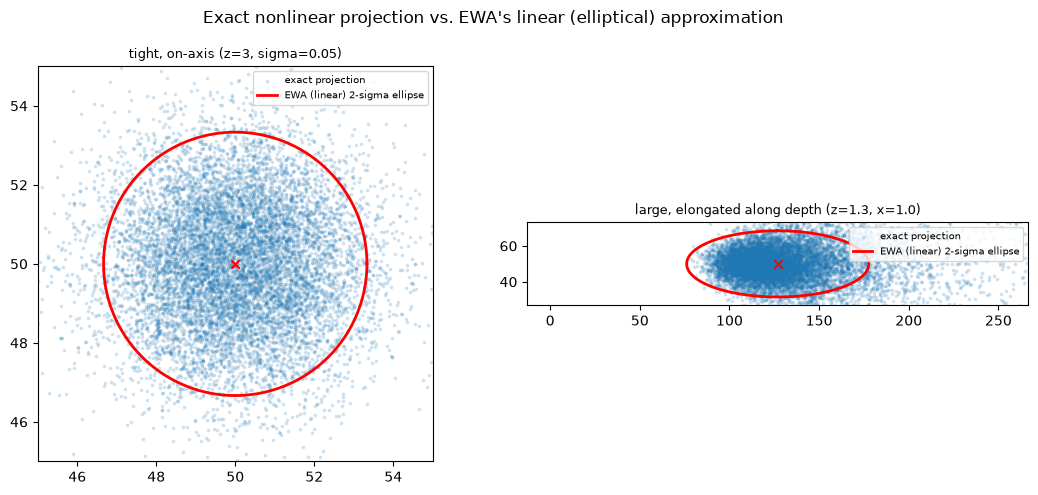

In [10]:
# Cell 18
# visual demo: sample points from a 3D gaussian in camera space, push them
# through the *exact* nonlinear projection, and compare the resulting scatter
# against the ellipse EWA's linear (Jacobian) approximation predicts -- once
# for a small gaussian (relative to its distance) and once for a large one
# elongated along the viewing (depth) axis, which exaggerates the effect since
# it's specifically depth spread that the 1/z nonlinearity distorts.

def project_exact(xyz, fx, fy, cx, cy):
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    u = fx * x / z + cx
    v = fy * y / z + cy
    return np.stack([u, v], axis=-1)


def ellipse_from_cov(mean_2d, cov_2d, n_std=2.0, n_pts=200):
    """Points tracing the n_std-sigma contour of a 2D gaussian (mean_2d, cov_2d)."""
    vals, vecs = np.linalg.eigh(cov_2d)
    theta = np.linspace(0, 2 * np.pi, n_pts)
    circle = np.stack([np.cos(theta), np.sin(theta)])
    ellipse = vecs @ (np.sqrt(np.clip(vals, 0, None))[:, None] * circle) * n_std
    return mean_2d[:, None] + ellipse


fx, fy, cx, cy = 100.0, 100.0, 50.0, 50.0
rng = np.random.default_rng(0)

# (label, mean in camera space, per-axis sigma [sx,sy,sz], (zoom_x, zoom_y))
configs = [
    ("tight, on-axis (z=3, sigma=0.05)", np.array([0.0, 0.0, 3.0]), np.array([0.05, 0.05, 0.05]), (3.0, 3.0)),
    ("large, elongated along depth (z=1.3, x=1.0)", np.array([1.0, 0.0, 1.3]), np.array([0.12, 0.12, 0.4]), (5.5, 2.5)),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (label, mean_cam, sigmas, zoom) in zip(axes, configs):
    cov_cam = np.diag(sigmas ** 2)
    samples = rng.multivariate_normal(mean_cam, cov_cam, size=10000)
    samples = samples[samples[:, 2] > 1e-2]  # drop the rare sample that crosses behind the camera
    proj = project_exact(samples, fx, fy, cx, cy)

    # EWA's linear approximation: the Jacobian evaluated at the gaussian's own mean
    x, y, z = mean_cam
    J = np.array([[fx / z, 0, -fx * x / z ** 2],
                  [0, fy / z, -fy * y / z ** 2]])
    mean_2d = np.array([fx * x / z + cx, fy * y / z + cy])
    cov_2d = J @ cov_cam @ J.T

    ax.scatter(proj[:, 0], proj[:, 1], s=3, alpha=0.15, label="exact projection")
    ellipse = ellipse_from_cov(mean_2d, cov_2d)
    ax.plot(ellipse[0], ellipse[1], color="red", lw=2, label="EWA (linear) 2-sigma ellipse")
    ax.scatter(*mean_2d, color="red", marker="x", zorder=5)

    zoom_x, zoom_y = zoom
    half_span_x = zoom_x * np.sqrt(cov_2d[0, 0])
    half_span_y = zoom_y * np.sqrt(cov_2d[1, 1])
    ax.set_xlim(mean_2d[0] - half_span_x, mean_2d[0] + half_span_x)
    ax.set_ylim(mean_2d[1] - half_span_y, mean_2d[1] + half_span_y)
    ax.set_title(label, fontsize=9)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=7)
fig.suptitle("Exact nonlinear projection vs. EWA's linear (elliptical) approximation")
plt.tight_layout()
plt.show()

In [11]:
# Cell 19
def quat_to_rotmat(q):
    """(...,4) unit quaternion (w,x,y,z) -> (...,3,3) rotation matrix."""
    w, x, y, z = q.unbind(-1)
    R = torch.stack([
        1 - 2 * (y ** 2 + z ** 2), 2 * (x * y - z * w), 2 * (x * z + y * w),
        2 * (x * y + z * w), 1 - 2 * (x ** 2 + z ** 2), 2 * (y * z - x * w),
        2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x ** 2 + y ** 2),
    ], dim=-1)
    return R.reshape(*q.shape[:-1], 3, 3)


def project_gaussians(camera, gaussians, near_eps=2e-2, dilation=0.3):
    """Returns (mean_2d_x, mean_2d_y, Sigma_2d, depth, visible)."""
    means = gaussians.means
    R = torch.as_tensor(camera.R, dtype=torch.float32)
    t = torch.as_tensor(camera.t, dtype=torch.float32)
    fx, fy, cx, cy = camera.fx, camera.fy, camera.cx, camera.cy

    scales = gaussians.get_scales()
    quats = gaussians.get_rotations()

    means_cam = means @ R.T + t
    x_cam, y_cam, z_cam = means_cam[:, 0], means_cam[:, 1], means_cam[:, 2]
    visible = z_cam > near_eps
    z_safe = z_cam.clamp(min=near_eps)

    mean_2d_x = fx * x_cam / z_safe + cx
    mean_2d_y = fy * y_cam / z_safe + cy

    # Sigma_world = M M^T, M = R_q * diag(scale)
    Rq = quat_to_rotmat(quats)
    M = Rq * scales.unsqueeze(-2)
    Sigma_world = M @ M.transpose(-1, -2)

    Sigma_cam = R.unsqueeze(0) @ Sigma_world @ R.T.unsqueeze(0)

    zeros = torch.zeros_like(z_safe)
    J = torch.stack([
        torch.stack([fx / z_safe, zeros, -fx * x_cam / z_safe ** 2], dim=-1),
        torch.stack([zeros, fy / z_safe, -fy * y_cam / z_safe ** 2], dim=-1),
    ], dim=-2)  # (N,2,3)

    Sigma_2d = J @ Sigma_cam @ J.transpose(-1, -2)
    # a small "dilation" floor so even tiny/skinny gaussians still cover >=1 pixel
    Sigma_2d = Sigma_2d + dilation * torch.eye(2)

    return mean_2d_x, mean_2d_y, Sigma_2d, z_safe, visible

<!-- Cell 20 -->

### Sanity check

Put one isotropic gaussian directly in front of a simple axis-aligned camera and compare against a hand-derived closed form. With `R = I`, `t = 0`, a gaussian at `(0, 0, z)` should project to exactly the principal point `(cx, cy)`, and (since the Jacobian's off-diagonal terms vanish at `x=y=0`) the projected covariance should be exactly `scale^2 * (f/z)^2 * I + dilation * I`.

In [12]:
# Cell 21
dummy_cam = Camera(name="dummy", width=100, height=100, fx=100.0, fy=100.0, cx=50.0, cy=50.0,
                    R=np.eye(3), t=np.zeros(3), image=np.zeros((100, 100, 3), dtype=np.float32))
scale, opacity, color = 0.1, 0.8, (0.9, 0.2, 0.1)
test_gaussian = GaussianModel(
    means=np.array([[0.0, 0.0, 3.0]], dtype=np.float32),
    log_scales=np.full((1, 3), math.log(scale), dtype=np.float32),
    quats=np.array([[1.0, 0.0, 0.0, 0.0]], dtype=np.float32),
    opacity_logits=inverse_sigmoid(np.array([[opacity]], dtype=np.float32)),
    features_dc=rgb_to_sh_dc(torch.tensor([list(color)])).unsqueeze(1).numpy(),
    features_rest=np.zeros((1, NUM_SH_COEFFS - 1, 3), dtype=np.float32),
)

mean_2d_x, mean_2d_y, Sigma_2d, depth, visible = project_gaussians(dummy_cam, test_gaussian)
print(f"projected mean: ({mean_2d_x.item():.4f}, {mean_2d_y.item():.4f}), expected (50, 50)")

z = 3.0
expected_var = (scale ** 2) * (dummy_cam.fx / z) ** 2 + 0.3
print(f"projected covariance:\n{Sigma_2d[0].detach().numpy()}")
print(f"expected (isotropic): diag({expected_var:.4f}, {expected_var:.4f})")

projected mean: (50.0000, 50.0000), expected (50, 50)
projected covariance:
[[11.411112  0.      ]
 [ 0.       11.411112]]
expected (isotropic): diag(11.4111, 11.4111)


<!-- Cell 22 -->

## 5. Rasterization: alpha-compositing gaussians into an image

Now turn projected 2D gaussians into a picture. Sort near-to-far, and composite each one onto its own small pixel patch using the classic Porter-Duff **"over" operator**: `color += alpha * transmittance * gaussian_color`, then `transmittance *= (1 - alpha)`. This is exactly what a tile-based CUDA rasterizer does -- just processed one gaussian at a time here, in plain PyTorch, instead of many tiles in parallel on a GPU (the "naive, no performance engineering" trade-off that makes this notebook CPU-friendly).

Color is no longer a fixed per-gaussian value -- it's evaluated from the SH coefficients (Section 2) at the direction from each gaussian to *this* camera, so the same gaussian can render a different color from different viewpoints once it has learned non-zero higher-order SH coefficients.

In [13]:
# Cell 23
def render(camera, gaussians, background=(0.0, 0.0, 0.0), near_eps=2e-2,
           dilation=0.3, track_grads=False):
    """Returns an (H,W,3) float image. If track_grads, also returns the
    screen-space means (with .grad populated after backward()) and a
    visibility mask -- the signal adaptive density control needs (Section 8)."""
    H, W = camera.height, camera.width
    opacities = gaussians.get_opacities().squeeze(-1)

    camera_center = torch.as_tensor(camera.camera_center, dtype=torch.float32)
    view_dirs = F.normalize(gaussians.means - camera_center, dim=-1)
    colors = sh_to_rgb(eval_sh(gaussians.active_sh_degree, gaussians.get_features(), view_dirs))

    mean_2d_x, mean_2d_y, Sigma_2d, z_safe, visible = project_gaussians(
        camera, gaussians, near_eps=near_eps, dilation=dilation)

    means2d = torch.stack([mean_2d_x, mean_2d_y], dim=-1)
    if track_grads:
        means2d.retain_grad()

    # sort near -> far for correct alpha-compositing order; drop invisible gaussians
    order = torch.nonzero(visible, as_tuple=True)[0]
    order = order[torch.argsort(z_safe[order])]

    bg = torch.as_tensor(background, dtype=torch.float32)
    if order.numel() == 0:
        image = bg.expand(H, W, 3).clone()
        return (image, means2d, visible) if track_grads else image

    # gather every per-gaussian quantity into near->far order once, up front --
    # everything below this point just composites, with no more sorting/gathering
    means2d_sorted = means2d[order]
    Sigma_inv_sorted = torch.linalg.inv(Sigma_2d[order])
    opacities_sorted = opacities[order]
    colors_sorted = colors[order]

    # gaussian weight at every pixel, for every (sorted) gaussian, all at once:
    # exp(-1/2 (p - mean)^T Sigma^-1 (p - mean))
    ys, xs = torch.meshgrid(torch.arange(H, dtype=torch.float32),
                             torch.arange(W, dtype=torch.float32), indexing="ij")
    pixels = torch.stack([xs, ys], dim=-1)                       # (H,W,2)
    diff = pixels[None] - means2d_sorted[:, None, None, :]       # (N,H,W,2)
    power = -0.5 * torch.einsum("nhwi,nij,nhwj->nhw", diff, Sigma_inv_sorted, diff)
    weight = torch.exp(power.clamp(max=0.0))
    alpha = (opacities_sorted[:, None, None] * weight).clamp(0.0, 0.9999)  # (N,H,W)

    # alpha-composite near -> far via cumulative transmittance, all at once
    # (same Porter-Duff "over" recursion as before: color += alpha*T*color_i,
    # T *= 1-alpha -- just expressed as one cumulative product instead of a loop)
    T = torch.cumprod(torch.cat([torch.ones(1, H, W), (1 - alpha)[:-1]], dim=0), dim=0)
    C = ((alpha * T).unsqueeze(-1) * colors_sorted[:, None, None, :]).sum(dim=0)
    T_final = T[-1] * (1 - alpha[-1])

    image = C + T_final.unsqueeze(-1) * bg
    return (image, means2d, visible) if track_grads else image

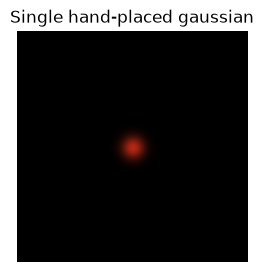

center pixel = [0.71999997 0.16       0.08      ], expected opacity*color = [0.72 0.16 0.08]

Gradients reach every parameter: True


In [14]:
# Cell 24
image = render(dummy_cam, test_gaussian)
plt.figure(figsize=(3, 3))
plt.imshow(image.detach().numpy())
plt.title("Single hand-placed gaussian")
plt.axis("off")
plt.show()

center = image[50, 50].detach().numpy()
print(f"center pixel = {center}, expected opacity*color = {opacity * np.array(color)}")

image.sum().backward()
print("\nGradients reach every parameter:",
      all(p.grad is not None for p in test_gaussian.parameters()))

<!-- Cell 25 -->

## 6. Photometric loss

Compare a rendered image against the real photo with `0.8 * L1 + 0.2 * (1 - SSIM)` -- the paper's loss. L1 alone is a fine pixel-wise error metric but doesn't care about local structure; SSIM (structural similarity, computed here with a small windowed gaussian blur) rewards getting local contrast/structure right, which tends to produce visually sharper results.

In [15]:
# Cell 26
def _gaussian_1d(window_size, sigma):
    coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    return g / g.sum()


def _ssim_window(window_size, channels, sigma=1.5):
    g1d = _gaussian_1d(window_size, sigma).unsqueeze(1)
    g2d = g1d @ g1d.t()
    return g2d.expand(channels, 1, window_size, window_size).contiguous()


# 11px was tuned for a 100x100 image (11% of its width); scale that same
# fraction to the downsampled image and round to the nearest odd size (SSIM
# windows need a single center pixel), floor of 3.
SSIM_WINDOW_SIZE = max(3, round(11 / DOWNSAMPLE_FACTOR) // 2 * 2 + 1)


def ssim(img1, img2, window_size=SSIM_WINDOW_SIZE):
    """img1, img2: (H,W,C) in [0,1]. Returns a scalar mean SSIM."""
    img1 = img1.permute(2, 0, 1).unsqueeze(0)
    img2 = img2.permute(2, 0, 1).unsqueeze(0)
    channels = img1.shape[1]
    window = _ssim_window(window_size, channels)
    pad = window_size // 2

    mu1 = F.conv2d(img1, window, padding=pad, groups=channels)
    mu2 = F.conv2d(img2, window, padding=pad, groups=channels)
    mu1_sq, mu2_sq, mu1_mu2 = mu1 * mu1, mu2 * mu2, mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=channels) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=channels) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=pad, groups=channels) - mu1_mu2

    C1, C2 = 0.01 ** 2, 0.03 ** 2
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
               ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()


def photometric_loss(rendered, gt, lambda_dssim=0.2):
    l1 = (rendered - gt).abs().mean()
    s = ssim(rendered, gt)
    loss = (1 - lambda_dssim) * l1 + lambda_dssim * (1 - s)
    return loss, l1.item(), s.item()

<!-- Cell 27 -->

## 7. Adaptive density control

Before writing the training loop, one more piece: gaussians need to be able to change *how many* of them there are. Too few, and the model can't represent fine detail; leftover useless ones waste compute. The paper's heuristic: track how much each gaussian's *screen-space position* wants to move (the gradient of the loss w.r.t. its projected 2D mean) across several training steps. A gaussian that consistently wants to move a lot is "under-reconstructing" some region -- so periodically:

- **clone** small high-gradient gaussians in place (letting the optimizer pull the pair apart over subsequent steps)
- **split** large high-gradient gaussians into two smaller ones
- **prune** low-opacity or oversized gaussians
- periodically **reset opacity** to a low value, forcing low-utility gaussians to re-earn it (or get pruned next round) instead of persisting as dead weight

Growing or shrinking the gaussian count mid-training means also doing surgery on Adam's per-parameter momentum state, not just the model's parameters -- `_replace_param` below handles that.

In [16]:
# Cell 28
PARAM_NAMES = ["means", "log_scales", "quats", "opacity_logits", "features_dc", "features_rest"]
GROUP_NAME = {"means": "means", "log_scales": "scaling", "quats": "rotation",
              "opacity_logits": "opacity", "features_dc": "sh_dc", "features_rest": "sh_rest"}


class DensificationStats:
    """Accumulates per-gaussian screen-space position-gradient magnitude
    between densification steps."""

    def __init__(self, n):
        self.grad_accum = torch.zeros(n)
        self.denom = torch.zeros(n)

    def update(self, means2d_grad, visible):
        norm = means2d_grad.norm(dim=-1)
        self.grad_accum[visible] += norm[visible]
        self.denom[visible] += 1

    def average_grad(self):
        return self.grad_accum / self.denom.clamp(min=1)

    def reset(self, n):
        self.grad_accum = torch.zeros(n)
        self.denom = torch.zeros(n)


def _inverse_sigmoid_t(x, eps=1e-6):
    x = x.clamp(eps, 1 - eps)
    return torch.log(x / (1 - x))


def _replace_param(optimizer, gaussians, name, new_tensor):
    """Swap one GaussianModel parameter for `new_tensor`, resetting that
    parameter's Adam momentum. Works for both growing (concatenated) and
    shrinking (masked-down) cases."""
    group_name = GROUP_NAME[name]
    for group in optimizer.param_groups:
        if group["name"] != group_name:
            continue
        old_param = group["params"][0]
        optimizer.state.pop(old_param, None)
        new_param = nn.Parameter(new_tensor.detach().clone())
        group["params"][0] = new_param
        setattr(gaussians, name, new_param)
        return new_param
    raise ValueError(f"no optimizer group named {group_name!r}")


def densify_and_prune(gaussians, optimizer, stats, grad_threshold, scene_extent,
                       min_opacity=0.005, percent_dense=0.01, max_scale_frac=0.1):
    """One densify+prune step. Returns the new gaussian count."""
    grads = stats.average_grad()
    scales = gaussians.get_scales().detach()
    max_scale = scales.max(dim=-1).values

    candidates = grads >= grad_threshold
    clone_mask = candidates & (max_scale <= percent_dense * scene_extent)
    split_mask = candidates & (max_scale > percent_dense * scene_extent)

    current = {name: getattr(gaussians, name).detach() for name in PARAM_NAMES}
    new_chunks = {name: [] for name in PARAM_NAMES}

    if clone_mask.any():
        for name in PARAM_NAMES:
            new_chunks[name].append(current[name][clone_mask].clone())

    split_idx = torch.nonzero(split_mask, as_tuple=True)[0]
    if split_idx.numel() > 0:
        rot = quat_to_rotmat(gaussians.get_rotations().detach()[split_idx])
        scale = scales[split_idx]
        samples = torch.randn(2, split_idx.numel(), 3) * scale.unsqueeze(0)
        offsets = torch.einsum("kij,skj->ski", rot, samples)
        smaller_log_scales = current["log_scales"][split_idx] - torch.log(torch.tensor(1.6))
        for s in range(2):
            new_chunks["means"].append(current["means"][split_idx] + offsets[s])
            new_chunks["log_scales"].append(smaller_log_scales.clone())
            new_chunks["quats"].append(current["quats"][split_idx].clone())
            new_chunks["opacity_logits"].append(current["opacity_logits"][split_idx].clone())
            new_chunks["features_dc"].append(current["features_dc"][split_idx].clone())
            new_chunks["features_rest"].append(current["features_rest"][split_idx].clone())

    keep_mask = ~split_mask  # split originals are replaced; clone originals stay
    for name in PARAM_NAMES:
        pieces = [current[name][keep_mask]] + new_chunks[name]
        _replace_param(optimizer, gaussians, name, torch.cat(pieces, dim=0))
    stats.reset(gaussians.n_gaussians)

    prune_mask = gaussians.get_opacities().detach().squeeze(-1) < min_opacity
    big_mask = gaussians.get_scales().detach().max(dim=-1).values > max_scale_frac * scene_extent
    prune_mask = prune_mask | big_mask
    if prune_mask.any():
        keep = ~prune_mask
        for name in PARAM_NAMES:
            _replace_param(optimizer, gaussians, name, getattr(gaussians, name).detach()[keep])
        stats.reset(gaussians.n_gaussians)

    return gaussians.n_gaussians


def reset_opacity(gaussians, optimizer, value=0.01):
    capped = gaussians.get_opacities().detach().clamp(max=value)
    _replace_param(optimizer, gaussians, "opacity_logits", _inverse_sigmoid_t(capped))

<!-- Cell 29 -->

## 8. The training loop

Everything comes together here: per-parameter-group Adam learning rates (position gets its own exponentially-decaying schedule, scaled by scene size), the progressive SH-degree ramp from Section 2, periodic density control from Section 7, and a held-out test split for an honest quality check.

All the interval constants below (density-control timing, SH-degree ramp rate) are scaled down from the official 30,000-iteration schedule to this notebook's iteration count, keeping the same *ratios* -- e.g. the official code raises the SH degree every 1000 of 30,000 iterations (1/30 of training); we do the same fraction here.

In [17]:
# Cell 30
NUM_ITERS = 2500
LOG_EVERY = 50
PROGRESS_EVERY = 250

LR_POSITION_INIT = 1.6e-4
LR_POSITION_FINAL = 1.6e-6
LR_SCALING = 5e-3
LR_ROTATION = 1e-3
LR_OPACITY = 5e-2
LR_SH_DC = 2.5e-3
LR_SH_REST = LR_SH_DC / 20.0  # higher-order SH bands affect the image much less
                              # per-unit-change than the DC term, so they need a
                              # gentler lr to stay stable
LAMBDA_DSSIM = 0.2

DENSIFY_FROM_ITER = 100
DENSIFY_UNTIL_ITER = int(NUM_ITERS * 0.8)  # measured across seeds: 0.6 (paper's
                                            # ratio) left ~21% of final gaussians at
                                            # near-zero opacity -- once pruning stops,
                                            # gaussians that decay afterward are never
                                            # cleaned up. 0.8 nearly halves that (~12%)
                                            # and also slightly improves held-out
                                            # quality; pushing to 1.0 cleans up further
                                            # (~4%) but costs a bit of quality, likely
                                            # from pruning too close to the last iters
                                            # to let replacements refine
DENSIFY_INTERVAL = 100
DENSIFY_GRAD_THRESHOLD = 4e-5 * DOWNSAMPLE_FACTOR ** 2  # empirically calibrated
                                # for *pixel-space* gradients at 100x100 (not the
                                # paper's own NDC-space constant); photometric_loss
                                # averages over all pixels, so with fewer pixels each
                                # one's gradient carries more weight -- scaled by
                                # factor^2 as a starting point, may need re-tuning
OPACITY_RESET_INTERVAL = 500
MIN_OPACITY = 0.005
PERCENT_DENSE = 0.01
SH_DEGREE_INTERVAL = max(1, NUM_ITERS // 30)

# densify_and_prune (Section 7) deletes any gaussian bigger than
# max_scale_frac * scene_extent. Every gaussian starts at scale
# extent / N_POINTS_INIT**(1/3) (cell 15), so max_scale_frac must stay well
# above N_POINTS_INIT**(-1/3) or the very first prune pass deletes everything
# at once -- 2x headroom above that initial fraction, floored at the paper's
# own 0.1 default.
MAX_SCALE_FRAC = max(0.1, 2 * N_POINTS_INIT ** (-1 / 3))


def expon_lr(step, lr_init, lr_final, max_steps):
    t = np.clip(step / max_steps, 0.0, 1.0)
    return float(np.exp(np.log(lr_init) * (1 - t) + np.log(lr_final) * t))


scene_extent = compute_scene_extent(train_cameras)
lr_position_init = LR_POSITION_INIT * scene_extent
lr_position_final = LR_POSITION_FINAL * scene_extent

gaussians, _ = random_init_gaussians(train_cameras)

optimizer = torch.optim.Adam([
    {"params": [gaussians.means], "lr": lr_position_init, "name": "means"},
    {"params": [gaussians.log_scales], "lr": LR_SCALING, "name": "scaling"},
    {"params": [gaussians.quats], "lr": LR_ROTATION, "name": "rotation"},
    {"params": [gaussians.opacity_logits], "lr": LR_OPACITY, "name": "opacity"},
    {"params": [gaussians.features_dc], "lr": LR_SH_DC, "name": "sh_dc"},
    {"params": [gaussians.features_rest], "lr": LR_SH_REST, "name": "sh_rest"},
], eps=1e-15)
means_group = next(g for g in optimizer.param_groups if g["name"] == "means")

stats = DensificationStats(gaussians.n_gaussians)
progress_cameras = [train_cameras[i] for i in
                    np.linspace(0, len(train_cameras) - 1, 3).astype(int)]
progress_log = []
gaussian_snapshots = []  # periodic gaussian state (not just rendered images),
                          # for animating how the population itself evolves --
                          # captured at the same cadence as density control
                          # (DENSIFY_INTERVAL), since that's when gaussian
                          # count actually changes
losses = []

t_start = time.time()
for step in range(1, NUM_ITERS + 1):
    means_group["lr"] = expon_lr(step, lr_position_init, lr_position_final, NUM_ITERS)
    if step % SH_DEGREE_INTERVAL == 0:
        gaussians.active_sh_degree = min(gaussians.active_sh_degree + 1, MAX_SH_DEGREE)

    cam = train_cameras[np.random.randint(len(train_cameras))]
    gt = torch.from_numpy(cam.image)

    rendered, means2d, visible = render(cam, gaussians, track_grads=True)
    loss, l1_val, ssim_val = photometric_loss(rendered, gt, LAMBDA_DSSIM)

    optimizer.zero_grad()
    loss.backward()
    with torch.no_grad():
        stats.update(means2d.grad, visible)
    optimizer.step()
    losses.append(loss.item())

    if step == 5:
        per_iter = (time.time() - t_start) / step
        print(f"[timing] ~{per_iter:.3f}s/iter, projected total ~{per_iter * NUM_ITERS / 60:.1f} min")

    if DENSIFY_FROM_ITER <= step <= DENSIFY_UNTIL_ITER and step % DENSIFY_INTERVAL == 0:
        n = densify_and_prune(gaussians, optimizer, stats, DENSIFY_GRAD_THRESHOLD, scene_extent,
                               min_opacity=MIN_OPACITY, percent_dense=PERCENT_DENSE,
                               max_scale_frac=MAX_SCALE_FRAC)
        print(f"[densify] step {step:5d}: now {n} gaussians")

    if step % OPACITY_RESET_INTERVAL == 0 and step < DENSIFY_UNTIL_ITER:
        reset_opacity(gaussians, optimizer)
        print(f"[opacity reset] step {step:5d}")

    if step % LOG_EVERY == 0:
        print(f"step {step:5d}/{NUM_ITERS}  loss {loss.item():.4f}  L1 {l1_val:.4f}  "
              f"SSIM {ssim_val:.4f}  N {gaussians.n_gaussians}  SH {gaussians.active_sh_degree}")

    if step % PROGRESS_EVERY == 0 or step == NUM_ITERS:
        with torch.no_grad():
            imgs = [render(c, gaussians).clamp(0, 1).numpy() for c in progress_cameras]
        progress_log.append((step, imgs))

    if step % DENSIFY_INTERVAL == 0 or step == NUM_ITERS:
        with torch.no_grad():
            gaussian_snapshots.append({
                "step": step,
                "means": gaussians.means.detach().numpy().copy(),
                "rgb": sh_to_rgb(gaussians.features_dc.squeeze(1)).detach().clamp(0, 1).numpy().copy(),
                "opacity": gaussians.get_opacities().detach().numpy().squeeze(-1).copy(),
                "scales3": gaussians.get_scales().detach().numpy().copy(),
                "rotmats": quat_to_rotmat(gaussians.get_rotations().detach()).numpy().copy(),
            })

print(f"\ntraining done in {(time.time() - t_start) / 60:.1f} min")

[timing] ~0.019s/iter, projected total ~0.8 min


step    50/2500  loss 0.4149  L1 0.2850  SSIM 0.0653  N 500  SH 0


[densify] step   100: now 452 gaussians
step   100/2500  loss 0.3033  L1 0.1434  SSIM 0.0569  N 452  SH 1


step   150/2500  loss 0.2436  L1 0.0947  SSIM 0.1608  N 452  SH 1


[densify] step   200: now 61 gaussians
step   200/2500  loss 0.2533  L1 0.1404  SSIM 0.2952  N 61  SH 2


step   250/2500  loss 0.1830  L1 0.1049  SSIM 0.5044  N 61  SH 3


[densify] step   300: now 37 gaussians
step   300/2500  loss 0.1542  L1 0.0841  SSIM 0.5655  N 37  SH 3


step   350/2500  loss 0.1458  L1 0.0794  SSIM 0.5886  N 37  SH 3


[densify] step   400: now 47 gaussians
step   400/2500  loss 0.1439  L1 0.0716  SSIM 0.5666  N 47  SH 3


step   450/2500  loss 0.1559  L1 0.0955  SSIM 0.6024  N 47  SH 3


[densify] step   500: now 63 gaussians
[opacity reset] step   500
step   500/2500  loss 0.1432  L1 0.0645  SSIM 0.5420  N 63  SH 3


step   550/2500  loss 0.1748  L1 0.1051  SSIM 0.5466  N 63  SH 3


[densify] step   600: now 65 gaussians
step   600/2500  loss 0.1323  L1 0.0720  SSIM 0.6264  N 65  SH 3


step   650/2500  loss 0.1208  L1 0.0652  SSIM 0.6568  N 65  SH 3


[densify] step   700: now 86 gaussians
step   700/2500  loss 0.1270  L1 0.0717  SSIM 0.6516  N 86  SH 3


step   750/2500  loss 0.1044  L1 0.0582  SSIM 0.7109  N 86  SH 3


[densify] step   800: now 119 gaussians
step   800/2500  loss 0.1106  L1 0.0577  SSIM 0.6778  N 119  SH 3


step   850/2500  loss 0.1088  L1 0.0638  SSIM 0.7116  N 119  SH 3


[densify] step   900: now 153 gaussians
step   900/2500  loss 0.1022  L1 0.0519  SSIM 0.6967  N 153  SH 3


step   950/2500  loss 0.1041  L1 0.0530  SSIM 0.6918  N 153  SH 3


[densify] step  1000: now 178 gaussians
[opacity reset] step  1000
step  1000/2500  loss 0.0965  L1 0.0490  SSIM 0.7134  N 178  SH 3


step  1050/2500  loss 0.1128  L1 0.0721  SSIM 0.7242  N 178  SH 3


[densify] step  1100: now 176 gaussians
step  1100/2500  loss 0.0982  L1 0.0521  SSIM 0.7173  N 176  SH 3


step  1150/2500  loss 0.0841  L1 0.0495  SSIM 0.7776  N 176  SH 3


[densify] step  1200: now 201 gaussians
step  1200/2500  loss 0.0702  L1 0.0340  SSIM 0.7852  N 201  SH 3


step  1250/2500  loss 0.0865  L1 0.0410  SSIM 0.7316  N 201  SH 3


[densify] step  1300: now 228 gaussians
step  1300/2500  loss 0.0824  L1 0.0441  SSIM 0.7645  N 228  SH 3


step  1350/2500  loss 0.0887  L1 0.0432  SSIM 0.7293  N 228  SH 3


[densify] step  1400: now 244 gaussians
step  1400/2500  loss 0.0726  L1 0.0390  SSIM 0.7929  N 244  SH 3


step  1450/2500  loss 0.0962  L1 0.0491  SSIM 0.7154  N 244  SH 3


[densify] step  1500: now 265 gaussians
[opacity reset] step  1500
step  1500/2500  loss 0.0733  L1 0.0409  SSIM 0.7974  N 265  SH 3


step  1550/2500  loss 0.0770  L1 0.0458  SSIM 0.7981  N 265  SH 3


[densify] step  1600: now 264 gaussians
step  1600/2500  loss 0.0736  L1 0.0368  SSIM 0.7789  N 264  SH 3


step  1650/2500  loss 0.0609  L1 0.0348  SSIM 0.8347  N 264  SH 3


[densify] step  1700: now 270 gaussians
step  1700/2500  loss 0.0836  L1 0.0447  SSIM 0.7607  N 270  SH 3


step  1750/2500  loss 0.0555  L1 0.0315  SSIM 0.8488  N 270  SH 3


[densify] step  1800: now 280 gaussians
step  1800/2500  loss 0.0657  L1 0.0385  SSIM 0.8254  N 280  SH 3


step  1850/2500  loss 0.0736  L1 0.0392  SSIM 0.7890  N 280  SH 3


[densify] step  1900: now 289 gaussians
step  1900/2500  loss 0.0678  L1 0.0337  SSIM 0.7960  N 289  SH 3


step  1950/2500  loss 0.0619  L1 0.0313  SSIM 0.8157  N 289  SH 3


[densify] step  2000: now 296 gaussians
step  2000/2500  loss 0.0871  L1 0.0464  SSIM 0.7500  N 296  SH 3


step  2050/2500  loss 0.0601  L1 0.0287  SSIM 0.8144  N 296  SH 3


step  2100/2500  loss 0.0572  L1 0.0273  SSIM 0.8233  N 296  SH 3


step  2150/2500  loss 0.0716  L1 0.0364  SSIM 0.7876  N 296  SH 3


step  2200/2500  loss 0.0589  L1 0.0307  SSIM 0.8286  N 296  SH 3


step  2250/2500  loss 0.0567  L1 0.0288  SSIM 0.8319  N 296  SH 3


step  2300/2500  loss 0.0684  L1 0.0353  SSIM 0.7991  N 296  SH 3


step  2350/2500  loss 0.0543  L1 0.0289  SSIM 0.8442  N 296  SH 3


step  2400/2500  loss 0.0613  L1 0.0331  SSIM 0.8255  N 296  SH 3


step  2450/2500  loss 0.0446  L1 0.0258  SSIM 0.8803  N 296  SH 3


step  2500/2500  loss 0.0419  L1 0.0240  SSIM 0.8861  N 296  SH 3

training done in 0.5 min


<!-- Cell 31 -->

### Final gaussian parameter summary

Before looking at the loss curve or rendered results, a quick sanity check on the *parameters* training just learned: how confidently opaque the surviving gaussians ended up (Section 3), and how much of their color is genuinely view-dependent versus just a flat base color -- comparing each gaussian's higher-degree (1-3) SH coefficient magnitude against its degree-0 term (Section 2). Since most surfaces in this scene aren't shiny/specular, that ratio should stay small for most gaussians.

Opacity:
  min=0.0004  median=0.2160  mean=0.2799  max=0.9960

SH coefficient magnitude, per gaussian:
  degree-0 (DC):        min=0.2221  median=1.8225  mean=1.7548  max=3.4585
  degree 1-3 (rest):    min=0.0983  median=0.3107  mean=0.3195  max=0.6399
  rest / DC ratio:      min=0.0308  median=0.1785  mean=0.2444  max=1.2655


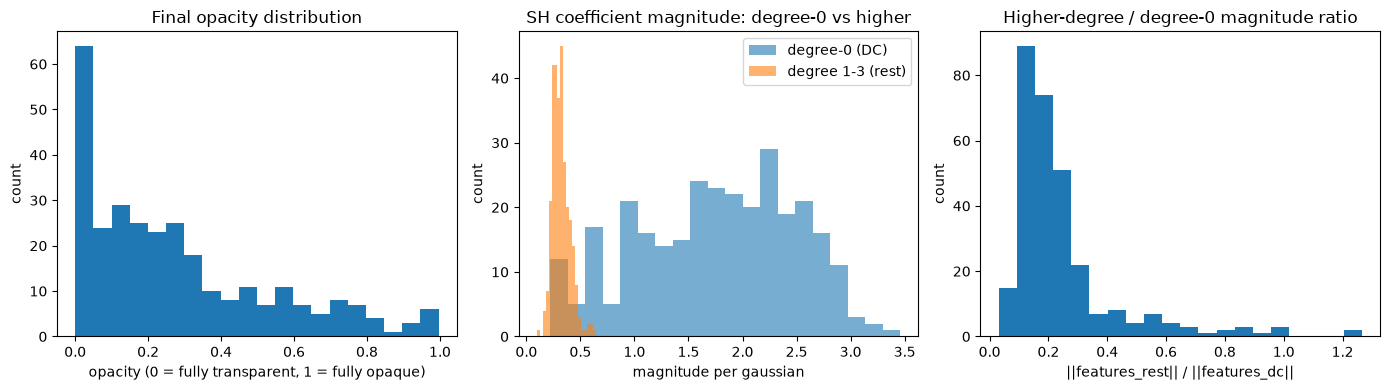

In [18]:
# Cell 32
# Summarize the final gaussians: opacity (Section 3) and the magnitude of
# their higher-degree (view-dependent) SH coefficients (Section 2) -- most
# gaussians should end up with only a small view-dependent contribution
# relative to their degree-0 (flat) color, since most surfaces here aren't
# very shiny/specular.
opacities_final = gaussians.get_opacities().detach().numpy().squeeze(-1)
print("Opacity:")
print(f"  min={opacities_final.min():.4f}  median={np.median(opacities_final):.4f}  "
      f"mean={opacities_final.mean():.4f}  max={opacities_final.max():.4f}")

sh_rest_final = gaussians.features_rest.detach().numpy()  # (N,15,3): degree 1-3 SH coefficients
sh_dc_final = gaussians.features_dc.detach().numpy()      # (N,1,3): degree 0 (flat-color) coefficient
sh_rest_magnitude = np.linalg.norm(sh_rest_final.reshape(len(sh_rest_final), -1), axis=-1)
sh_dc_magnitude = np.linalg.norm(sh_dc_final.reshape(len(sh_dc_final), -1), axis=-1)
sh_ratio = sh_rest_magnitude / np.clip(sh_dc_magnitude, 1e-6, None)  # per-gaussian, higher-degree vs degree-0

print("\nSH coefficient magnitude, per gaussian:")
print(f"  degree-0 (DC):        min={sh_dc_magnitude.min():.4f}  median={np.median(sh_dc_magnitude):.4f}  "
      f"mean={sh_dc_magnitude.mean():.4f}  max={sh_dc_magnitude.max():.4f}")
print(f"  degree 1-3 (rest):    min={sh_rest_magnitude.min():.4f}  median={np.median(sh_rest_magnitude):.4f}  "
      f"mean={sh_rest_magnitude.mean():.4f}  max={sh_rest_magnitude.max():.4f}")
print(f"  rest / DC ratio:      min={sh_ratio.min():.4f}  median={np.median(sh_ratio):.4f}  "
      f"mean={sh_ratio.mean():.4f}  max={sh_ratio.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(opacities_final, bins=20)
axes[0].set_title("Final opacity distribution")
axes[0].set_xlabel("opacity (0 = fully transparent, 1 = fully opaque)")
axes[0].set_ylabel("count")

axes[1].hist(sh_dc_magnitude, bins=20, alpha=0.6, label="degree-0 (DC)")
axes[1].hist(sh_rest_magnitude, bins=20, alpha=0.6, label="degree 1-3 (rest)")
axes[1].set_title("SH coefficient magnitude: degree-0 vs higher")
axes[1].set_xlabel("magnitude per gaussian")
axes[1].set_ylabel("count")
axes[1].legend()

axes[2].hist(sh_ratio, bins=20)
axes[2].set_title("Higher-degree / degree-0 magnitude ratio")
axes[2].set_xlabel("||features_rest|| / ||features_dc||")
axes[2].set_ylabel("count")
plt.tight_layout()
plt.show()

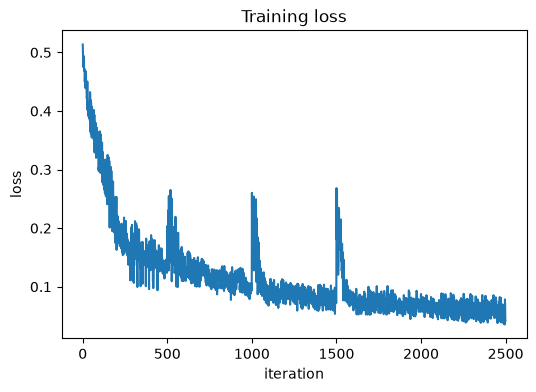

In [19]:
# Cell 33
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Training loss")
plt.show()

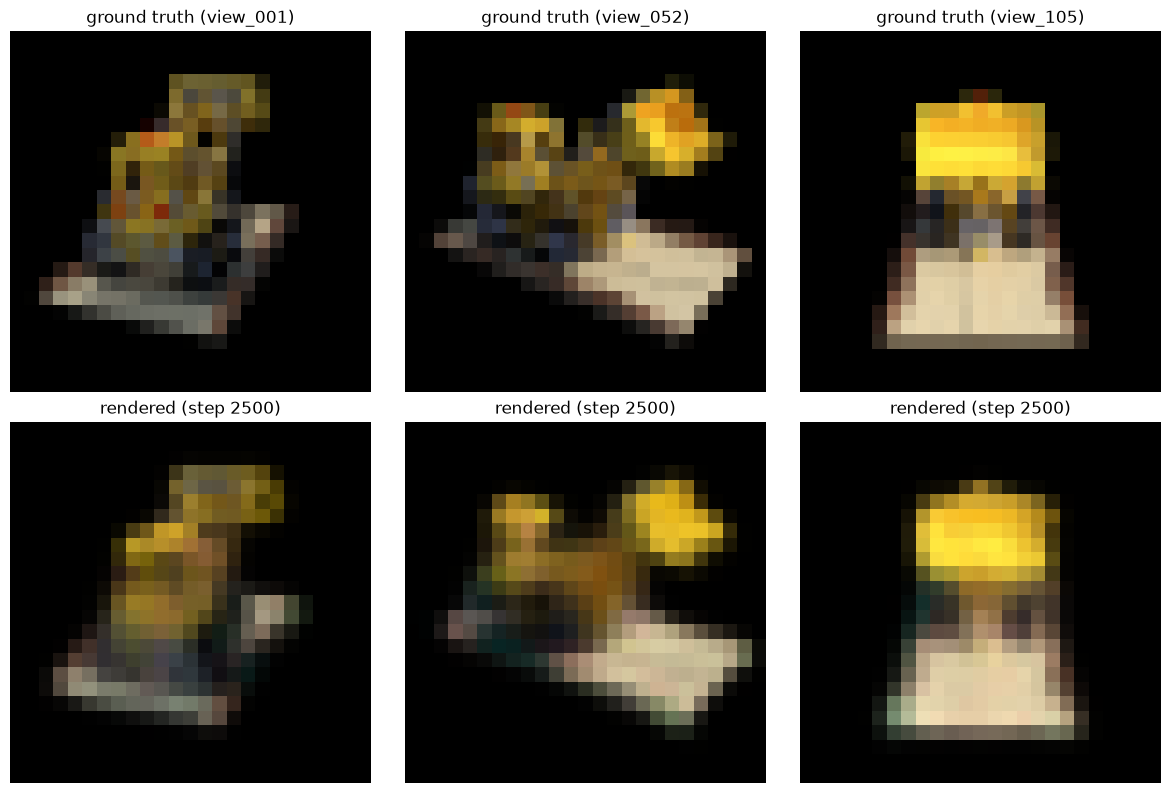

In [20]:
# Cell 34
last_step, last_imgs = progress_log[-1]
fig, axes = plt.subplots(2, len(progress_cameras), figsize=(4 * len(progress_cameras), 8))
for col, (cam, rendered) in enumerate(zip(progress_cameras, last_imgs)):
    axes[0, col].imshow(cam.image); axes[0, col].axis("off"); axes[0, col].set_title(f"ground truth ({cam.name})")
    axes[1, col].imshow(rendered); axes[1, col].axis("off"); axes[1, col].set_title(f"rendered (step {last_step})")
plt.tight_layout()
plt.show()

<!-- Cell 35 -->

## 9. Results

Two honest checks that the model actually learned the *scene*, not just how to reproduce the exact training photos:

1. **Held-out test L1** -- error on the views we never trained on (Section 1's `test_cameras`).
2. **A novel-view orbit** -- render a turnaround from camera angles that were never in the dataset at all, built by estimating the orbit axis/radius/elevation from the training camera poses (rather than assuming a fixed world "up" axis, which depends on how the source data was exported).

In [21]:
# Cell 36
test_l1s = []
with torch.no_grad():
    for cam in test_cameras:
        gt = torch.from_numpy(cam.image)
        rendered = render(cam, gaussians).clamp(0, 1)
        test_l1s.append((rendered - gt).abs().mean().item())
print(f"held-out test L1 (mean over {len(test_cameras)} views): {np.mean(test_l1s):.4f}")

held-out test L1 (mean over 14 views): 0.0309


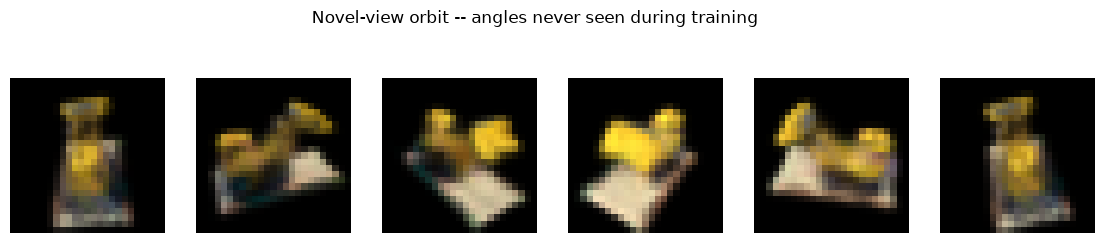

In [22]:
# Cell 37
def _perpendicular(axis):
    ref = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(ref, axis)) > 0.9:
        ref = np.array([0.0, 1.0, 0.0])
    return ref


def look_at_c2w(position, target, up_ref):
    z_axis = position - target
    z_axis = z_axis / np.linalg.norm(z_axis)
    x_axis = np.cross(up_ref, z_axis)
    x_norm = np.linalg.norm(x_axis)
    if x_norm < 1e-6:
        x_axis = np.cross(_perpendicular(z_axis), z_axis)
        x_norm = np.linalg.norm(x_axis)
    x_axis = x_axis / x_norm
    y_axis = np.cross(z_axis, x_axis)
    c2w = np.eye(4)
    c2w[:3, 0], c2w[:3, 1], c2w[:3, 2], c2w[:3, 3] = x_axis, y_axis, z_axis, position
    return c2w


def build_orbit_cameras(cams, points_xyz, n_frames=36):
    ref = cams[0]
    scene_center = points_xyz.mean(axis=0)
    centers = np.stack([c.camera_center for c in cams])
    dirs = centers - scene_center
    dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
    radius = float(np.linalg.norm(centers - scene_center, axis=1).mean())

    up_axis = dirs.mean(axis=0)
    up_axis = up_axis / np.linalg.norm(up_axis)
    polar_angle = np.arccos(np.clip(dirs @ up_axis, -1, 1)).mean()

    global_ref = _perpendicular(up_axis)
    u = np.cross(up_axis, global_ref); u = u / np.linalg.norm(u)
    v = np.cross(up_axis, u)

    orbit = []
    for i, alpha in enumerate(np.linspace(0, 2 * np.pi, n_frames, endpoint=False)):
        direction = np.sin(polar_angle) * (np.cos(alpha) * u + np.sin(alpha) * v) + np.cos(polar_angle) * up_axis
        position = scene_center + radius * direction
        c2w = look_at_c2w(position, scene_center, up_axis)
        R, t = nerf_c2w_to_w2c(c2w)
        orbit.append(Camera(name=f"orbit_{i:03d}", width=ref.width, height=ref.height,
                             fx=ref.fx, fy=ref.fy, cx=ref.cx, cy=ref.cy, R=R, t=t, image=None))
    return orbit


orbit_cameras = build_orbit_cameras(train_cameras, gaussians.means.detach().numpy(), n_frames=36)
with torch.no_grad():
    orbit_frames = [render(c, gaussians).clamp(0, 1).numpy() for c in orbit_cameras]

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, idx in zip(axes, np.linspace(0, len(orbit_frames) - 1, 6).astype(int)):
    ax.imshow(orbit_frames[idx]); ax.axis("off")
plt.suptitle("Novel-view orbit -- angles never seen during training")
plt.show()

In [23]:
# Cell 38
# Build the full orbit as an animated GIF in memory and display it directly --
# no need to write a file to disk just to view it here.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

def to_uint8(img):
    return (np.clip(img, 0.0, 1.0) * 255).round().astype(np.uint8)

gif_frames = [Image.fromarray(to_uint8(f)) for f in orbit_frames]
buf = io.BytesIO()
gif_frames[0].save(buf, format="GIF", save_all=True, append_images=gif_frames[1:], duration=1000 // 20, loop=0)
display(IPyImage(data=buf.getvalue()))

<!-- Cell 39 -->

## [Appendix] Additional visualization

In [24]:
# Cell 40
# Shared helpers for the two "gaussians as a 3D scatter" GIFs below: project
# each gaussian's covariance ellipsoid onto a view plane (same idea as the EWA
# projection in Section 4, just orthographic instead of perspective, so an
# elongated/anisotropic gaussian visibly changes apparent size with viewing
# angle), turn opacity into a marker alpha, render one frame, and stitch
# frames into an in-memory GIF.

def view_basis(elev_deg, azim_deg):
    """Two unit vectors spanning the view plane for this elev/azim (matches
    view_init's convention closely enough for this illustration)."""
    e, a = np.radians(elev_deg), np.radians(azim_deg)
    view_dir = np.array([np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e)])
    world_up = np.array([0.0, 0.0, 1.0])
    right = np.cross(world_up, view_dir); right /= np.linalg.norm(right)
    up = np.cross(view_dir, right); up /= np.linalg.norm(up)
    return np.stack([right, up])


def projected_area(scales3, rotmats, basis):
    """Project each gaussian's world-space covariance ellipsoid onto the view
    plane; returns a per-gaussian quantity proportional to its apparent area."""
    M = rotmats * scales3[:, None, :]
    Sigma_world = M @ M.transpose(0, 2, 1)
    Sigma_2d = np.einsum("ki,nij,lj->nkl", basis, Sigma_world, basis)
    return np.sqrt(np.clip(np.linalg.det(Sigma_2d), 0, None))


def marker_sizes_from_area(area, ref, base_size=45):
    return np.clip(base_size * area / ref, 3, 800)


def rgba_from_opacity(rgb, opacity, alpha_floor=0.1):
    """RGB + per-gaussian opacity -> RGBA, with a floor so near-zero-opacity
    gaussians stay faintly visible instead of disappearing."""
    alpha = alpha_floor + (1 - alpha_floor) * opacity
    return np.concatenate([rgb, alpha[:, None]], axis=-1)


def scatter_frame(xyz, rgba, marker_sizes, title, elev, azim, lims=None):
    """Render one 3D-scatter frame to a PIL Image."""
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(projection="3d")
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=marker_sizes, c=rgba)
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    if lims is not None:
        ax.set_xlim(lims[0]); ax.set_ylim(lims[1]); ax.set_zlim(lims[2])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def frames_to_gif(frames, duration):
    """Build a GIF in memory from PIL frames and display it directly."""
    buf = io.BytesIO()
    frames[0].save(buf, format="GIF", save_all=True, append_images=frames[1:], duration=duration, loop=0)
    display(IPyImage(data=buf.getvalue()))

<!-- Cell 41 -->

### Final gaussian positions, viewed from all angles

The rendered orbit above shows what the trained model *renders*; this shows what it actually *is*: the final gaussians themselves, spun around as a 3D point cloud. Each marker is one gaussian -- its color is that gaussian's base (SH degree-0) color, its transparency is its learned opacity, and its size/shape is its own covariance ellipsoid projected onto the current viewing angle (Section 4's EWA idea, just orthographic instead of perspective) -- so an elongated gaussian visibly changes apparent size as the view rotates, rather than being drawn as a fixed-size circle from every direction.

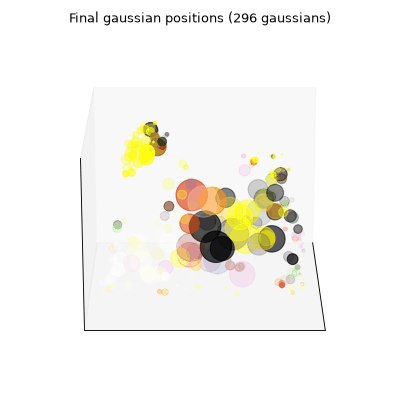

In [25]:
# Cell 42
# A different view of the same result: spin around the final gaussians'
# actual 3D positions, colored by base (SH degree-0) color with alpha from
# learned opacity, sized by each one's projected covariance ellipsoid (helpers
# above) -- built in memory and displayed directly, same as the rendered
# orbit above.
final_xyz = gaussians.means.detach().numpy()
final_rgba = rgba_from_opacity(
    sh_to_rgb(gaussians.features_dc.squeeze(1)).detach().clamp(0, 1).numpy(),
    gaussians.get_opacities().detach().numpy().squeeze(-1))
final_scales3 = gaussians.get_scales().detach().numpy()
final_rotmats = quat_to_rotmat(gaussians.get_rotations().detach()).numpy()

ELEV = 20
size_ref = None
scatter_frames = []
for angle in np.linspace(0, 360, 36, endpoint=False):
    basis = view_basis(ELEV, angle)
    area = projected_area(final_scales3, final_rotmats, basis)
    size_ref = size_ref if size_ref is not None else np.median(area)
    title = f"Final gaussian positions ({len(final_xyz)} gaussians)"
    scatter_frames.append(scatter_frame(final_xyz, final_rgba,
                                         marker_sizes_from_area(area, size_ref),
                                         title, ELEV, angle))

frames_to_gif(scatter_frames, duration=1000 // 20)

<!-- Cell 43 -->

### How the gaussian population evolves during training

This one doesn't rotate -- the viewpoint is fixed, so anything that changes between frames is purely a training effect. Each frame is a snapshot of the actual gaussians (not a render) taken periodically during the training loop (Section 8): watch the count collapse sharply in the first few hundred steps as gradient descent prunes gaussians with the "wrong" random position or color (Section 7), then gradually rebuild through cloning and splitting, while positions settle onto real structure and colors/opacities converge.

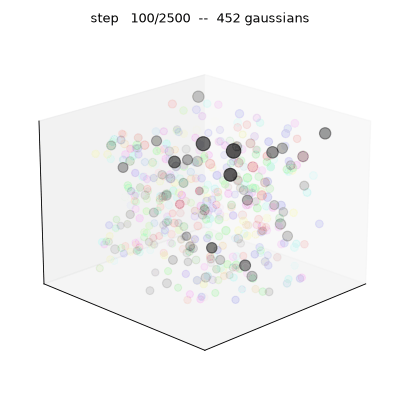

In [26]:
# Cell 44
# Same idea as the previous cell, but instead of spinning the final result
# around, watch the population itself evolve over training: one frame per
# gaussian_snapshots entry (Section 8), from a fixed viewpoint, so any change
# between frames is purely the training dynamics -- count crashing then
# rebuilding via density control, positions settling, colors/opacities
# converging -- not a change in camera angle.
ELEV_TRAIN, AZIM_TRAIN = 20, 45
basis_train = view_basis(ELEV_TRAIN, AZIM_TRAIN)

# fixed axis limits across every frame so the animation doesn't rescale/jitter
# as the point cloud grows and shifts
all_xyz = np.concatenate([snap["means"] for snap in gaussian_snapshots], axis=0)
pad = 0.05 * (all_xyz.max(axis=0) - all_xyz.min(axis=0)).max()
lims = list(zip(all_xyz.min(axis=0) - pad, all_xyz.max(axis=0) + pad))

train_frames = []
for snap in gaussian_snapshots:
    rgba = rgba_from_opacity(snap["rgb"], snap["opacity"])
    # normalized per-frame (unlike the fixed reference above) so each
    # snapshot's own relative anisotropy stays legible even as the
    # population's overall scale shrinks by orders of magnitude over training
    area = projected_area(snap["scales3"], snap["rotmats"], basis_train)
    title = f"step {snap['step']:5d}/{NUM_ITERS}  --  {len(snap['means'])} gaussians"
    train_frames.append(scatter_frame(snap["means"], rgba,
                                       marker_sizes_from_area(area, np.median(area)),
                                       title, ELEV_TRAIN, AZIM_TRAIN, lims=lims))

frames_to_gif(train_frames, duration=500)

<!-- Cell 45 -->

## 10. Extensions / next steps

This notebook deliberately leaves a few things on the table:

- **Real structure-from-motion initialization.** We started from a *random* point cloud (Section 3). A real pipeline runs COLMAP (`feature_extractor` -> `exhaustive_matcher` -> `point_triangulator`/`mapper`) to get a real sparse point cloud from features matched across the training photos -- giving the optimizer a real head start instead of guessing. **This is the natural next thing to add** -- the only function that needs to change is `random_init_gaussians` in Section 3; every camera, projection, rendering, loss, training, and density-control cell above works unchanged with any initial point cloud.
- **A tiled/CUDA rasterizer.** `render` here processes one gaussian at a time in plain PyTorch, which is why this notebook stays CPU-friendly at ~1000-3000 gaussians. The official implementation instead sorts gaussians into screen-space tiles and rasterizes many gaussians per tile in parallel on the GPU -- the same math, but able to scale to scenes with millions of gaussians in real time.

If you made it this far and both the math and the code feel like they hang together, you've built (a small, CPU-sized version of) a real 3D Gaussian Splatting pipeline from scratch.